# Fling

Graph layout by fitting a function of node features instead of a table of coordinates. Three
variants share the same field and differ only in the energy the weights are trained on.

In [1]:
import json
import pathlib
import sys

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

from fling import Fling, FlingStress, FlingVis, FlingBlend


def draw(pos, graph, ax, title):
    pos = np.asarray(pos, float)
    edges = np.array(graph.edges())
    ax.add_collection(LineCollection(pos[edges], colors="0.7", linewidths=0.4, alpha=0.6))
    ax.scatter(pos[:, 0], pos[:, 1], s=8, c="#b2182b", linewidths=0, zorder=2)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=9)

Any networkx graph works. Node labels have to be integers from zero.

In [2]:
graph = nx.convert_node_labels_to_integers(nx.les_miserables_graph())
print(graph)

Graph with 77 nodes and 254 edges


## The three variants

Fling minimises all pairs stress. FlingStress minimises pivot stress over sampled columns.
FlingVis carries a neighbour embedding with node edge clearance and crossing terms.

/home/daenu/Code/fling-layout/fling/estimators.py:373: RuntimeWarning: overflow encountered in scalar multiply
  z = key + np.uint64(0x9E3779B97F4A7C15) * np.uint64(column + 1 + 977 * self.seed)


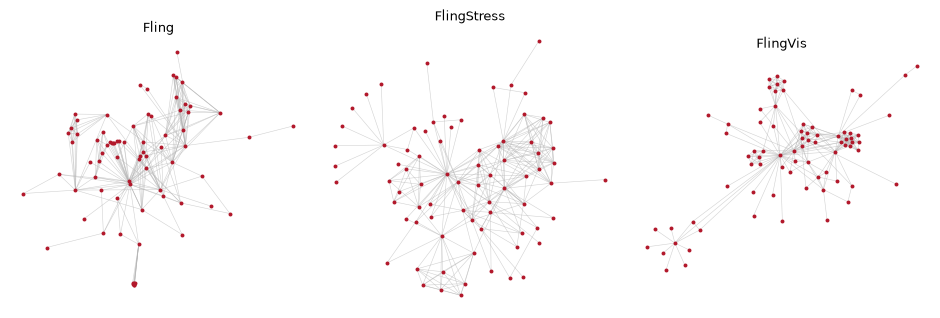

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
for ax, cls in zip(axes, (Fling, FlingStress, FlingVis)):
    pos = cls(n_components=2, seed=0).fit_transform(graph)
    draw(pos, graph, ax, cls.__name__)
fig.tight_layout()

## Adding nodes without refitting

The layout is a map from features to positions, so a node that was not in the fit gets a position
from one forward pass. Nothing is reoptimised and the old nodes do not move.

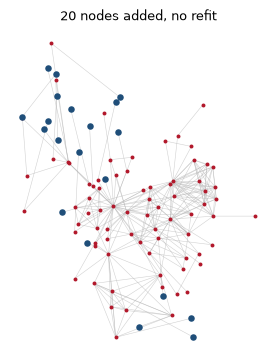

In [4]:
model = FlingStress(n_components=2, seed=0).fit(graph)

n = graph.number_of_nodes()
grown = graph.copy()
for i, v in enumerate(list(graph.nodes())[:20]):
    grown.add_edge(n + i, v)

pos = np.asarray(model.transform(grown), float)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
draw(pos, grown, ax, "20 nodes added, no refit")
ax.scatter(pos[n:, 0], pos[n:, 1], s=22, c="#1f4e79", linewidths=0, zorder=3)

## One fit, a whole family

FlingBlend conditions the field on the weight between two energies. One fit answers any weight, and
the members share a coordinate frame, so nothing needs aligning between them.

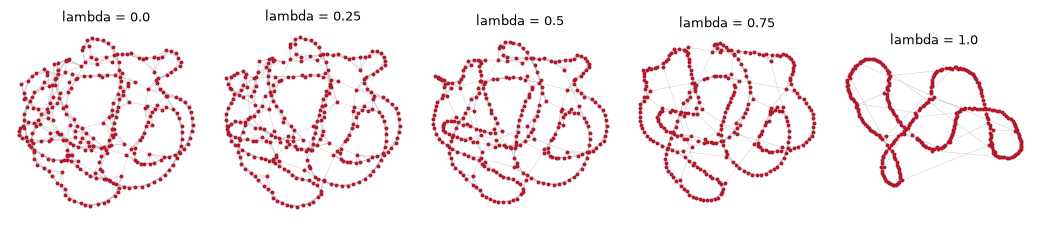

In [5]:
ring = nx.convert_node_labels_to_integers(nx.watts_strogatz_graph(300, 6, 0.02, seed=0))
family = FlingBlend(n_components=2, seed=0).fit(ring)

lams = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(lams), figsize=(2.1 * len(lams), 2.4))
for ax, lam in zip(axes, lams):
    draw(family.draw(lam), ring, ax, f"lambda = {lam}")
fig.tight_layout()

Stress at one end, neighbour preservation at the other. The panels in between were never fitted.

## A million nodes

The Pennsylvania road network from SNAP, 1,087,562 nodes and 1,541,514 edges. Fling runs on the GPU
and s_gd2 uses its sparse pivot variant on the CPU. `scripts/million.py` caches both layouts and
`scripts/draw_large.py` rasterises them with datashader, because matplotlib cannot draw a million
edges. Install it with `pip install datashader`.


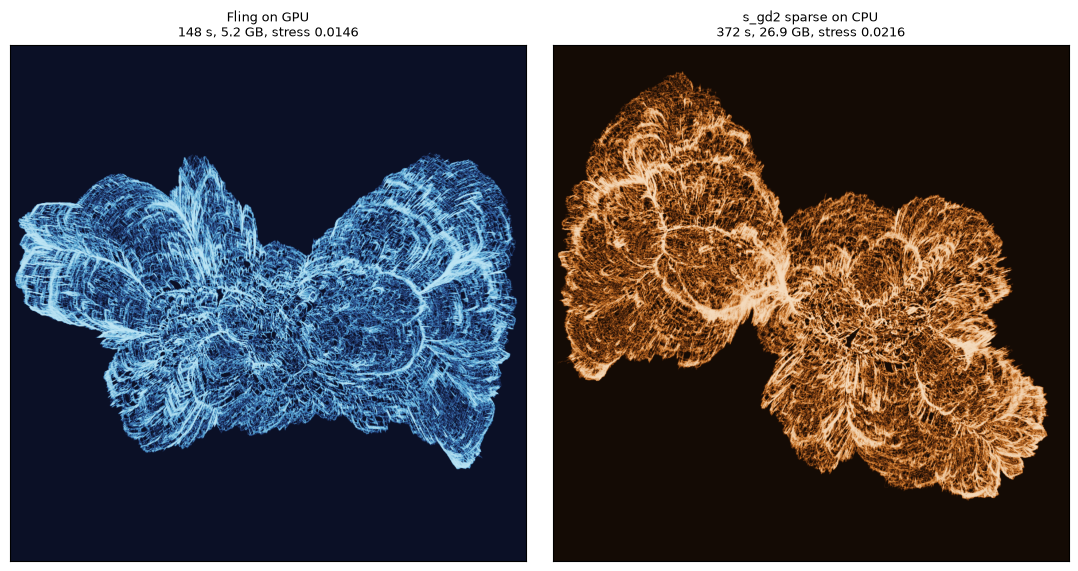

In [6]:
sys.path.insert(0, "scripts")
from draw_large import render
from million import build

roadnet = build("roadnet", 0, pathlib.Path("data"))
edges = np.array(roadnet.edges())
cache = pathlib.Path("cache/million")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, (arm, label) in zip(axes, (("fling", "Fling on GPU"),
                                   ("sgd2", "s_gd2 sparse on CPU"))):
    run = json.loads((cache / f"{arm}_roadnet_seed0.json").read_text())
    pos = np.load(cache / f"{arm}_roadnet_seed0.npy")
    ax.imshow(render(pos, edges, 900, arm))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{label}\n{run['t']:.0f} s, {run['host_mb'] / 1024:.1f} GB, "
                 f"stress {run['stress']:.4f}", fontsize=9)
fig.tight_layout()


Fling is faster, uses a fifth of the memory and gets the lower stress. Neither drawing is a
map of Pennsylvania though. Both fold the sheet onto itself, which is what a few hundred pivots buys
you on a graph this far across.
